# Evaluator: Visibility Degree

This notebook analyzes the four visibility-degree experiment outputs: **G → G**, **G → S**, **S → G**, and **S → S**. It focuses on rank figures and diversity figures:

1. **Four-line figure:** best solution rank across visibility degree, with each condition averaged across `K`.
2. **Averaged figure:** best solution rank across visibility degree, averaged across both `K` and the four G–S visibility conditions.
3. **Pairwise-diversity figures:** pairwise solution diversity across visibility degree, shown as one averaged line and as G-sender versus S-sender lines.

Smaller rank means a better discovered solution, so the y-axis is inverted in the rank figures.

In [12]:
import os
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from black import trans

legend_properties = {'weight': 'bold'}

# NUS colors
nus_blue = "#003D7C"
nus_orange = "#EF7C00"

# Nature three colors
nature_orange = "#F16C23"
nature_blue = "#2B6A99"
nature_green = "#1B7C3D"

# Morandi colors
morandi_blue = "#046586"
morandi_green = "#28A9A1"
morandi_yellow = "#C9A77C"
morandi_orange = "#F4A016"
morandi_pink = "#F6BBC6"
morandi_red = "#E71F19"
morandi_purple = "#B08BEB"

# Others
shallow_grey = "#D3D4D3"
deep_grey = "#A6ABB6"
strong_red = "#A61C5D"
strong_blue = "#1B64A4"

def format_axis(ax):
    """Use consistent axis formatting across figures."""
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["right"].set_linewidth(1.5)
    ax.spines["top"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)
    ax.grid(alpha=0.5)
    return ax


In [13]:
# =========================
# Configuration
# =========================
agent_num = 200
K_list = [1, 2, 3, 4, 5, 6, 7, 8]
visibility_prob_list = [0.0, 0.005, 0.01, 0.02, 0.04, 0.08,
                        0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
visibility_interval = 10

condition_order = ["gg", "gs", "sg", "ss"]
condition_labels = {
    "gg": "G → G",
    "gs": "G → S",
    "sg": "S → G",
    "ss": "S → S",
}
condition_colors = {
    "gg": morandi_blue,
    "gs": morandi_orange,
    "sg": morandi_green,
    "ss": morandi_purple,
}

dv_labels = {
    "breakthrough_rank": "Best solution rank",
    "breakthrough_fitness": "Best solution fitness",
    "diversity": "Diversity",
    "pairwise_diversity": "Pairwise solution diversity",
}

# Candidate folders. The evaluator will choose the first folder that contains
# gg_visibility_prob_*_interval_20_breakthrough_rank_across_K_size_200 files.
candidate_folders = [
    Path(r"/Volumes/T7/data/gst-0924-26/Visibility_degree_low_knowledge"),
    Path.cwd(),
]

def folder_has_visibility_degree_results(folder):
    if not folder.exists():
        return False
    pattern = f"gg_visibility_prob_*_interval_{visibility_interval}_breakthrough_rank_across_K_size_{agent_num}"
    return any(folder.glob(pattern))

result_folder = next(
    (folder for folder in candidate_folders if folder_has_visibility_degree_results(folder)),
    candidate_folders[0],
)

# To force a specific folder, uncomment and edit this line:
# result_folder = Path(r"/Volumes/T7/data/gst-0112-26/Maturity")

print("Result folder:", result_folder)
print("Visibility interval:", visibility_interval)
print("Folder exists:", result_folder.exists())

if result_folder.exists():
    available_files = sorted(p.name for p in result_folder.iterdir())
else:
    available_files = []

print("Number of files in folder:", len(available_files))
print("First 10 files:")
for name in available_files[:3]:
    print("  ", name)


Result folder: /Volumes/T7/data/gst-0924-26/Visibility_degree_low_knowledge
Visibility interval: 10
Folder exists: True
Number of files in folder: 814
First 10 files:
   ._Crowd.py
   ._Evaluator.ipynb
   ._G_send_to_G_visibility_degree.py


In [14]:
# =========================
# Load visibility-degree results
# =========================
def load_pickle(path):
    with open(path, "rb") as infile:
        return pickle.load(infile)

def result_file(prefix, visibility_prob, dv):
    return result_folder / f"{prefix}_visibility_prob_{visibility_prob}_interval_{visibility_interval}_{dv}_across_K_size_{agent_num}"

def load_visibility_degree_results(prefixes=condition_order, strict=True):
    """Load result arrays.

    Expected shape for each data[prefix][dv]:
        (len(visibility_prob_list), len(K_list))

    Each row corresponds to a visibility degree.
    Each column corresponds to a K value.
    """
    data = {}
    missing_files = []
    wrong_length = []

    for prefix in prefixes:
        data[prefix] = {}

        for dv in dv_labels:
            rows = []

            for visibility_prob in visibility_prob_list:
                path = result_file(prefix, visibility_prob, dv)

                if not path.exists():
                    missing_files.append(path)
                    continue

                values = np.asarray(load_pickle(path), dtype=float)
                if len(values) != len(K_list):
                    wrong_length.append((path.name, len(values)))

                rows.append(values)

            if rows:
                data[prefix][dv] = np.vstack(rows)

    if wrong_length:
        print("\nFiles with unexpected K dimension:")
        for name, length in wrong_length[:30]:
            print(f"  - {name}: length={length}; expected={len(K_list)}")
        if len(wrong_length) > 30:
            print(f"  ... and {len(wrong_length) - 30} more")

    if missing_files:
        print("\nMissing files:")
        for path in missing_files[:30]:
            print("  -", path.name)
        if len(missing_files) > 30:
            print(f"  ... and {len(missing_files) - 30} more")

        print("\nPossible causes:")
        print("1. result_folder is not the folder where the scripts saved outputs.")
        print("2. Some scripts have not finished.")
        print("3. agent_num is different from the saved file name.")
        print("4. File prefix is different, e.g., gg/gs/sg/ss.")
        print("5. The visibility probability grid differs from visibility_prob_list.")
        print("6. visibility_interval is different from the saved file name.")

        if strict:
            raise FileNotFoundError("Some expected visibility-degree result files are missing.")

    return data

data = load_visibility_degree_results(strict=True)

print("\nLoaded data shapes:")
for prefix in condition_order:
    for dv in data[prefix]:
        print(prefix, dv, data[prefix][dv].shape)



Loaded data shapes:
gg breakthrough_rank (16, 8)
gg breakthrough_fitness (16, 8)
gg diversity (16, 8)
gg pairwise_diversity (16, 8)
gs breakthrough_rank (16, 8)
gs breakthrough_fitness (16, 8)
gs diversity (16, 8)
gs pairwise_diversity (16, 8)
sg breakthrough_rank (16, 8)
sg breakthrough_fitness (16, 8)
sg diversity (16, 8)
sg pairwise_diversity (16, 8)
ss breakthrough_rank (16, 8)
ss breakthrough_fitness (16, 8)
ss diversity (16, 8)
ss pairwise_diversity (16, 8)


Averaging across K values: [2, 3, 4, 5, 6, 7, 8, 9]


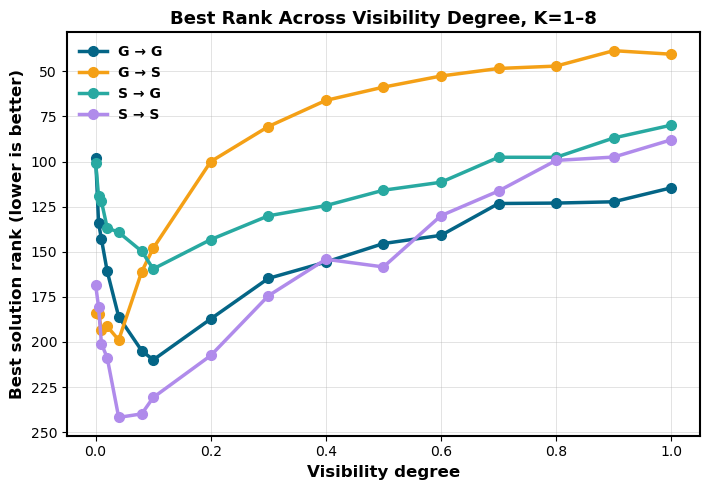

Saved: /Volumes/T7/data/gst-0924-26/Visibility_degree_low_knowledge/fig1_four_conditions_K2_to_K9.png


In [15]:
# =========================
# Figure 1 variant: Four-line figure with adjustable K averaging scope
# =========================
fig, ax = plt.subplots(figsize=(7.2, 5.0))
format_axis(ax)

x = visibility_prob_list

# -------------------------
# Adjust K averaging scope here
# -------------------------
K_min = 1
K_max = 8

K_indices = [
    i for i, K in enumerate(K_list)
    if K_min <= K <= K_max
]

if len(K_indices) == 0:
    raise ValueError(f"No K values found in the range K_min={K_min} to K_max={K_max}.")

print("Averaging across K values:", [K_list[i] + 1 for i in K_indices])

for prefix in condition_order:
    # Average only across selected K values.
    # data[prefix]["breakthrough_rank"] shape:
    #   (visibility degree, K)
    y = data[prefix]["breakthrough_rank"][:, K_indices].mean(axis=1)

    ax.plot(
        x, y,
        marker="o", linewidth=2.5, markersize=7,
        label=condition_labels[prefix],
        color=condition_colors[prefix],
    )

ax.invert_yaxis()  # smaller rank means better solution; invert so better is visually higher
ax.set_xlabel("Visibility degree", fontweight="bold", fontsize=12)
ax.set_ylabel("Best solution rank (lower is better)", fontweight="bold", fontsize=12)
ax.set_title(
    f"Best Rank Across Visibility Degree, K={K_min}–{K_max}",
    fontweight="bold",
    fontsize=13,
)
ax.legend(frameon=False, prop=legend_properties)

plt.tight_layout()

output_png = result_folder / f"fig1_four_conditions_K{K_min + 1}_to_K{K_max + 1}.png"
plt.savefig(output_png, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

print("Saved:", output_png)

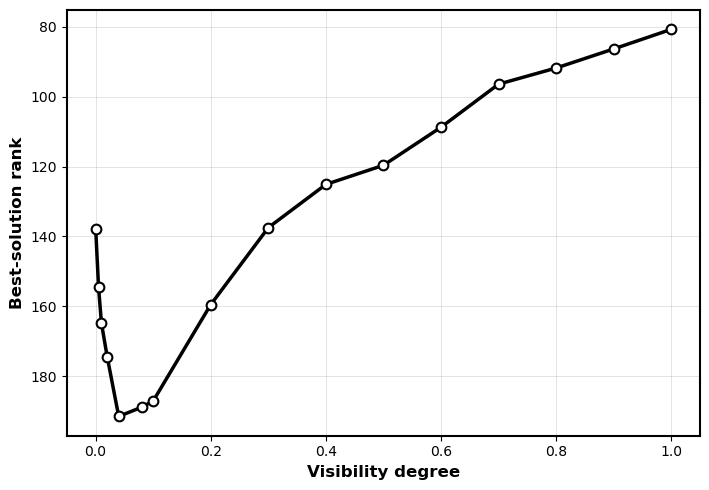

Saved: /Volumes/T7/data/gst-0924-26/Visibility_degree_low_knowledge/fig2_average.png


In [16]:
# =========================
# Figure 2: Averaged figure — best solution rank across visibility degree
# averaged across G-S combinations and K
# =========================
fig, ax = plt.subplots(figsize=(7.2, 5.0))
format_axis(ax)

x = visibility_prob_list

# First average each condition across K; then average across the four G-S visibility conditions.
y = np.mean(
    [data[prefix]["breakthrough_rank"].mean(axis=1) for prefix in condition_order],
    axis=0,
)

ax.plot(x, y, marker="o", linewidth=2.5, markersize=7, color="k",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.5,)

ax.invert_yaxis()
ax.set_xlabel("Visibility degree", fontweight="bold", fontsize=12)
ax.set_ylabel("Best-solution rank", fontweight="bold", fontsize=12)
# ax.set_title("Best Rank Across Visibility Degree", fontweight="bold", fontsize=13)
plt.tight_layout()

output_png = result_folder / "fig2_average.png"
plt.savefig(output_png, dpi=300, bbox_inches="tight", transparent=True)
plt.show()
print("Saved:", output_png)


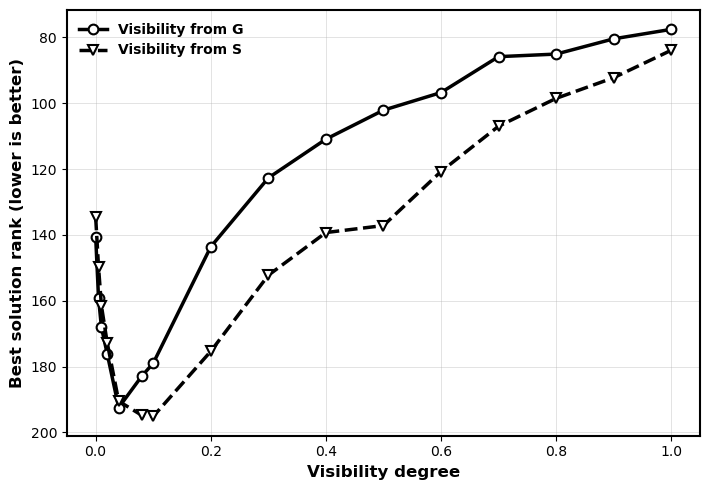

Saved: /Volumes/T7/data/gst-0924-26/Visibility_degree_low_knowledge/fig3_sender_type.png


In [17]:
# =========================
# Figure 3: Sender-direction figure — G as sender vs. S as sender
# averaged across receiver type and K
# Black-and-white version with different markers
# =========================
fig, ax = plt.subplots(figsize=(7.2, 5.0))
format_axis(ax)

x = visibility_prob_list

sender_groups = {
    "Visibility from G": ["gg", "gs"],  # G → G and G → S
    "Visibility from S": ["sg", "ss"],  # S → G and S → S
}

sender_styles = {
    "Visibility from G": {"linestyle": "-", "marker": "o"},
    "Visibility from S": {"linestyle": "--", "marker": "v"},
}

for label, prefixes in sender_groups.items():
    # Average across receiver conditions and K.
    # Shape before averaging:
    #   each data[prefix]["breakthrough_rank"] has shape
    #   (visibility degree, K)
    y = np.mean(
        [data[prefix]["breakthrough_rank"] for prefix in prefixes],
        axis=0,
    ).mean(axis=1)

    ax.plot(
        x, y,
        color="black",
        linestyle=sender_styles[label]["linestyle"],
        marker=sender_styles[label]["marker"],
        linewidth=2.5,
        markersize=7,
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.5,
        label=label,
    )

ax.invert_yaxis()  # smaller rank means better solution; invert so better is visually higher
ax.set_xlabel("Visibility degree", fontweight="bold", fontsize=12)
ax.set_ylabel("Best solution rank (lower is better)", fontweight="bold", fontsize=12)
# ax.set_title("Best Rank Across Visibility Degree by Sender Type", fontweight="bold", fontsize=13)
ax.legend(frameon=False, prop=legend_properties)

plt.tight_layout()

output_png = result_folder / "fig3_sender_type.png"

plt.savefig(output_png, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

print("Saved:", output_png)


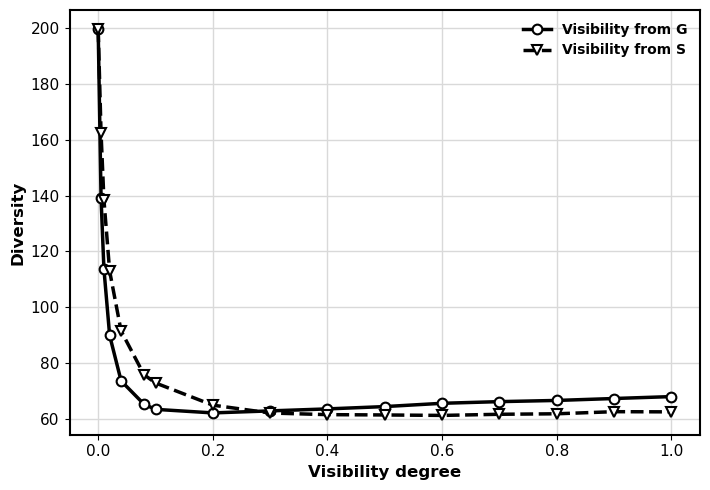

Saved: /Volumes/T7/data/gst-0924-26/Visibility_degree_low_knowledge/fig4_sender_type_diversity.png


In [18]:
# =========================
# Figure 3: Sender-direction figure — G as sender vs. S as sender
# Y-axis: diversity
# =========================

with plt.rc_context({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
    "grid.color": "0.85",
}):
    fig, ax = plt.subplots(figsize=(7.2, 5.0))
    format_axis(ax)

    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.5)

    ax.tick_params(axis="both", colors="black", labelsize=11)

    x = visibility_prob_list

    sender_groups = {
        "Visibility from G": ["gg", "gs"],
        "Visibility from S": ["sg", "ss"],
    }

    sender_styles = {
        "Visibility from G": {"linestyle": "-",  "marker": "o"},
        "Visibility from S": {"linestyle": "--", "marker": "v"},
    }

    for label, prefixes in sender_groups.items():
        # Average diversity across receiver conditions and K.
        y = np.mean(
            [data[prefix]["diversity"] for prefix in prefixes],
            axis=0,
        ).mean(axis=1)

        ax.plot(
            x, y,
            color="black",
            linestyle=sender_styles[label]["linestyle"],
            marker=sender_styles[label]["marker"],
            linewidth=2.5,
            markersize=7,
            markerfacecolor="white",
            markeredgecolor="black",
            markeredgewidth=1.5,
            label=label,
        )

    ax.set_xlabel("Visibility degree", fontweight="bold", fontsize=12, color="black")
    ax.set_ylabel("Diversity", fontweight="bold", fontsize=12, color="black")
    # ax.set_title(
    #     "Diversity Across Visibility Degree by Sender Type",
    #     fontweight="bold",
    #     fontsize=13,
    #     color="black",
    # )

    ax.grid(True, color="0.85", linewidth=1.0, alpha=1.0)

    legend = ax.legend(frameon=False, prop=legend_properties)
    for text in legend.get_texts():
        text.set_color("black")

    plt.tight_layout()

    output_png = result_folder / "fig4_sender_type_diversity.png"
    plt.savefig(output_png, dpi=300, bbox_inches="tight", transparent=True)
    plt.show()

    print("Saved:", output_png)

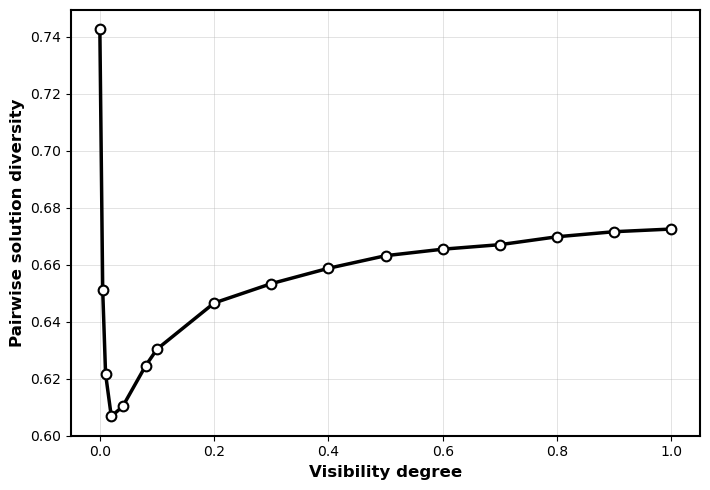

Saved: /Volumes/T7/data/gst-0924-26/Visibility_degree_low_knowledge/fig5_average_pairwise_diversity.png


In [19]:
# =========================
# Figure 5: Averaged figure — pairwise solution diversity across visibility degree
# averaged across G-S combinations and K
# =========================
fig, ax = plt.subplots(figsize=(7.2, 5.0))
format_axis(ax)

x = visibility_prob_list

# First average each condition across K; then average across the four G-S visibility conditions.
y = np.mean(
    [data[prefix]["pairwise_diversity"].mean(axis=1) for prefix in condition_order],
    axis=0,
)

ax.plot(x, y, marker="o", linewidth=2.5, markersize=7, color="k",
            markerfacecolor="white",
            markeredgecolor="black",
            markeredgewidth=1.5,)

ax.set_xlabel("Visibility degree", fontweight="bold", fontsize=12)
ax.set_ylabel("Pairwise solution diversity", fontweight="bold", fontsize=12)
# ax.set_title("(b)  Solution Diversity across Visibility Degree", fontweight="bold", fontsize=13)
plt.tight_layout()

output_png = result_folder / "fig5_average_pairwise_diversity.png"
plt.savefig(output_png, dpi=300, bbox_inches="tight", transparent=True)
plt.show()
print("Saved:", output_png)


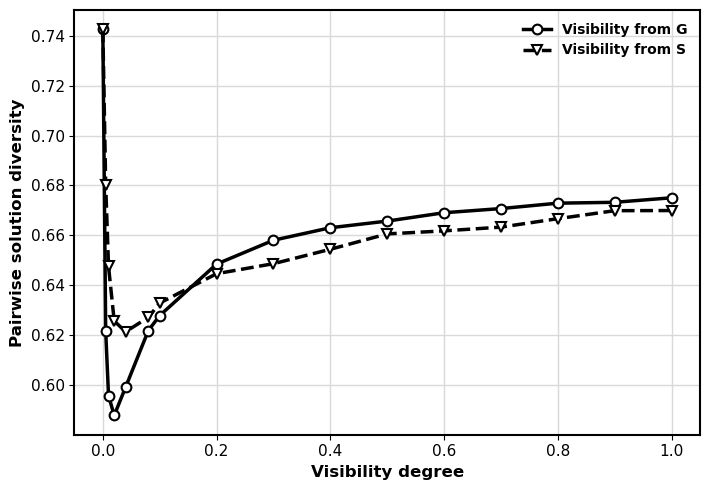

Saved: /Volumes/T7/data/gst-0924-26/Visibility_degree_low_knowledge/fig6_sender_type_pairwise_diversity.png


In [20]:
# =========================
# Figure 6: Sender-direction figure — G as sender vs. S as sender
# Y-axis: pairwise solution diversity
# =========================

with plt.rc_context({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
    "grid.color": "0.85",
}):
    fig, ax = plt.subplots(figsize=(7.2, 5.0))
    format_axis(ax)

    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.5)

    ax.tick_params(axis="both", colors="black", labelsize=11)

    x = visibility_prob_list

    sender_groups = {
        "Visibility from G": ["gg", "gs"],
        "Visibility from S": ["sg", "ss"],
    }

    sender_styles = {
        "Visibility from G": {"linestyle": "-",  "marker": "o"},
        "Visibility from S": {"linestyle": "--", "marker": "v"},
    }

    for label, prefixes in sender_groups.items():
        # Average pairwise diversity across receiver conditions and K.
        y = np.mean(
            [data[prefix]["pairwise_diversity"] for prefix in prefixes],
            axis=0,
        ).mean(axis=1)

        ax.plot(
            x, y,
            color="black",
            linestyle=sender_styles[label]["linestyle"],
            marker=sender_styles[label]["marker"],
            linewidth=2.5,
            markersize=7,
            markerfacecolor="white",
            markeredgecolor="black",
            markeredgewidth=1.5,
            label=label,
        )

    ax.set_xlabel("Visibility degree", fontweight="bold", fontsize=12, color="black")
    ax.set_ylabel("Pairwise solution diversity", fontweight="bold", fontsize=12, color="black")
    # ax.set_title(
    #     "Pairwise Diversity Across Visibility Degree by Sender Type",
    #     fontweight="bold",
    #     fontsize=13,
    #     color="black",
    # )

    ax.grid(True, color="0.85", linewidth=1.0, alpha=1.0)

    legend = ax.legend(frameon=False, prop=legend_properties)
    for text in legend.get_texts():
        text.set_color("black")

    plt.tight_layout()

    output_png = result_folder / "fig6_sender_type_pairwise_diversity.png"
    plt.savefig(output_png, dpi=300, bbox_inches="tight", transparent=True)
    plt.show()

    print("Saved:", output_png)


## Additional analysis: adopted-solution fitness

The cells below extend the evaluator to the two newly saved outputs without changing any of the existing analyses or figures above:

- `adopted_solution_fitness`: mean **true fitness** of solutions actually adopted by receivers, conditional on adoption.
- `adopted_solution_fitness_across_time`: cumulative mean adopted-solution fitness recorded at each visibility event.

The scalar measure is analyzed across visibility degree using the same figure formats as the existing rank analysis.  
The trajectory measure is analyzed across search time at an adjustable visibility degree, again using the same four-condition, overall-average, and sender-type views.

Because no solution is adopted when a run has no adoption events (especially at visibility degree `0`), these measures can contain `NaN`. The added cells use `np.nanmean` so undefined observations do not get incorrectly treated as zero.


In [21]:
import warnings

# =========================
# Load newly added adoption-quality results
# =========================
adoption_dvs = [
    "adopted_solution_fitness",
    "adopted_solution_fitness_across_time",
]

def load_adoption_quality_results(prefixes=condition_order, strict=True):
    """Load the two newly added adoption-quality outputs.

    Expected shapes:
        adoption_data[prefix]["adopted_solution_fitness"]:
            (visibility degree, K)

        adoption_data[prefix]["adopted_solution_fitness_across_time"]:
            (visibility degree, K, visibility event)

    The time-series file is saved as a list across K, where each K entry is
    the cumulative mean adopted-solution fitness across visibility events.
    """
    adoption_data = {}
    missing_files = []
    shape_problems = []

    for prefix in prefixes:
        adoption_data[prefix] = {}

        scalar_rows = []
        trajectory_rows = []

        for visibility_prob in visibility_prob_list:
            scalar_path = result_file(
                prefix,
                visibility_prob,
                "adopted_solution_fitness",
            )
            trajectory_path = result_file(
                prefix,
                visibility_prob,
                "adopted_solution_fitness_across_time",
            )

            if not scalar_path.exists():
                missing_files.append(scalar_path)
            if not trajectory_path.exists():
                missing_files.append(trajectory_path)

            if (not scalar_path.exists()) or (not trajectory_path.exists()):
                continue

            scalar_values = np.asarray(load_pickle(scalar_path), dtype=float)
            trajectory_values = np.asarray(load_pickle(trajectory_path), dtype=float)

            if scalar_values.ndim != 1 or scalar_values.shape[0] != len(K_list):
                shape_problems.append(
                    (
                        scalar_path.name,
                        scalar_values.shape,
                        f"expected ({len(K_list)},)",
                    )
                )

            if trajectory_values.ndim != 2 or trajectory_values.shape[0] != len(K_list):
                shape_problems.append(
                    (
                        trajectory_path.name,
                        trajectory_values.shape,
                        f"expected ({len(K_list)}, n_visibility_events)",
                    )
                )

            scalar_rows.append(scalar_values)
            trajectory_rows.append(trajectory_values)

        if scalar_rows:
            adoption_data[prefix]["adopted_solution_fitness"] = np.vstack(scalar_rows)

        if trajectory_rows:
            try:
                adoption_data[prefix]["adopted_solution_fitness_across_time"] = np.stack(
                    trajectory_rows,
                    axis=0,
                )
            except ValueError:
                shape_problems.append(
                    (
                        f"{prefix}: adopted_solution_fitness_across_time",
                        [row.shape for row in trajectory_rows],
                        "all visibility degrees must have the same time-series shape",
                    )
                )

    if shape_problems:
        print("\nFiles with unexpected shapes:")
        for name, observed, expected in shape_problems[:30]:
            print(f"  - {name}: observed={observed}; {expected}")
        if len(shape_problems) > 30:
            print(f"  ... and {len(shape_problems) - 30} more")

        if strict:
            raise ValueError("Some adoption-quality result files have unexpected shapes.")

    if missing_files:
        print("\nMissing newly added adoption-quality files:")
        for path in missing_files[:30]:
            print("  -", path.name)
        if len(missing_files) > 30:
            print(f"  ... and {len(missing_files) - 30} more")

        if strict:
            raise FileNotFoundError(
                "Some expected adoption-quality result files are missing."
            )

    return adoption_data


adoption_data = load_adoption_quality_results(strict=True)

print("\nLoaded adoption-quality data shapes:")
for prefix in condition_order:
    for dv in adoption_data[prefix]:
        print(prefix, dv, adoption_data[prefix][dv].shape)



Loaded adoption-quality data shapes:
gg adopted_solution_fitness (16, 8)
gg adopted_solution_fitness_across_time (16, 8, 30)
gs adopted_solution_fitness (16, 8)
gs adopted_solution_fitness_across_time (16, 8, 30)
sg adopted_solution_fitness (16, 8)
sg adopted_solution_fitness_across_time (16, 8, 30)
ss adopted_solution_fitness (16, 8)
ss adopted_solution_fitness_across_time (16, 8, 30)


Averaging across K values: [1, 2, 3, 4, 5, 6, 7, 8]


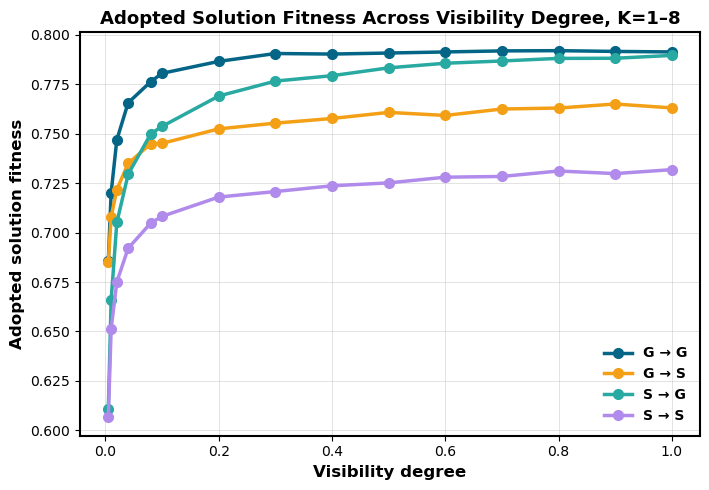

Saved: /Volumes/T7/data/gst-0924-26/Visibility_degree_low_knowledge/fig7_four_conditions_adopted_solution_fitness_K1_to_K8.png


In [22]:
# =========================
# Figure 7: Four-line figure — adopted solution fitness across visibility degree
# with adjustable K averaging scope
# =========================
fig, ax = plt.subplots(figsize=(7.2, 5.0))
format_axis(ax)

x = visibility_prob_list

# -------------------------
# Adjust K averaging scope here
# -------------------------
adoption_K_min = 1
adoption_K_max = 8

adoption_K_indices = [
    i for i, K in enumerate(K_list)
    if adoption_K_min <= K <= adoption_K_max
]

if len(adoption_K_indices) == 0:
    raise ValueError(
        f"No K values found in the range "
        f"adoption_K_min={adoption_K_min} to adoption_K_max={adoption_K_max}."
    )

print("Averaging across K values:", [K_list[i] for i in adoption_K_indices])

for prefix in condition_order:
    # Average across the selected K values.
    # Shape: (visibility degree, K)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        y = np.nanmean(
            adoption_data[prefix]["adopted_solution_fitness"][:, adoption_K_indices],
            axis=1,
        )

    ax.plot(
        x, y,
        marker="o", linewidth=2.5, markersize=7,
        label=condition_labels[prefix],
        color=condition_colors[prefix],
    )

ax.set_xlabel("Visibility degree", fontweight="bold", fontsize=12)
ax.set_ylabel("Adopted solution fitness", fontweight="bold", fontsize=12)
ax.set_title(
    f"Adopted Solution Fitness Across Visibility Degree, "
    f"K={adoption_K_min}–{adoption_K_max}",
    fontweight="bold",
    fontsize=13,
)
ax.legend(frameon=False, prop=legend_properties)

plt.tight_layout()

output_png = result_folder / (
    f"fig7_four_conditions_adopted_solution_fitness_"
    f"K{adoption_K_min}_to_K{adoption_K_max}.png"
)
plt.savefig(output_png, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

print("Saved:", output_png)


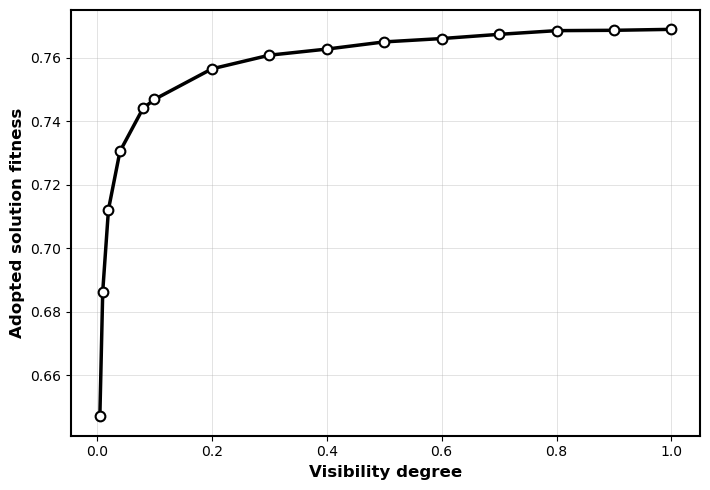

Saved: /Volumes/T7/data/gst-0924-26/Visibility_degree_low_knowledge/fig8_average_adopted_solution_fitness.png


In [23]:
# =========================
# Figure 8: Averaged figure — adopted solution fitness across visibility degree
# averaged across G-S combinations and K
# =========================
fig, ax = plt.subplots(figsize=(7.2, 5.0))
format_axis(ax)

x = visibility_prob_list

# Stack shape: (condition, visibility degree, K)
_adoption_stack = np.stack(
    [
        adoption_data[prefix]["adopted_solution_fitness"]
        for prefix in condition_order
    ],
    axis=0,
)

# Average across both condition and K, while leaving all-NaN points as NaN.
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    y = np.nanmean(_adoption_stack, axis=(0, 2))

ax.plot(
    x, y,
    marker="o", linewidth=2.5, markersize=7, color="k",
    markerfacecolor="white",
    markeredgecolor="black",
    markeredgewidth=1.5,
)

ax.set_xlabel("Visibility degree", fontweight="bold", fontsize=12)
ax.set_ylabel("Adopted solution fitness", fontweight="bold", fontsize=12)
# ax.set_title(
#     "Adopted Solution Fitness Across Visibility Degree",
#     fontweight="bold",
#     fontsize=13,
# )

plt.tight_layout()

output_png = result_folder / "fig8_average_adopted_solution_fitness.png"
plt.savefig(output_png, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

print("Saved:", output_png)


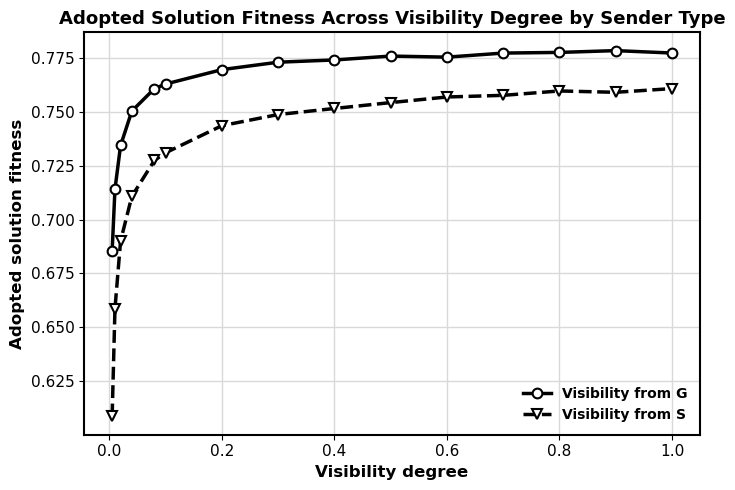

Saved: /Volumes/T7/data/gst-0924-26/Visibility_degree_low_knowledge/fig9_sender_type_adopted_solution_fitness.png


In [24]:
# =========================
# Figure 9: Sender-direction figure — G as sender vs. S as sender
# Y-axis: adopted solution fitness
# =========================
with plt.rc_context({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
    "grid.color": "0.85",
}):
    fig, ax = plt.subplots(figsize=(7.2, 5.0))
    format_axis(ax)

    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.5)

    ax.tick_params(axis="both", colors="black", labelsize=11)

    x = visibility_prob_list

    sender_groups = {
        "Visibility from G": ["gg", "gs"],
        "Visibility from S": ["sg", "ss"],
    }

    sender_styles = {
        "Visibility from G": {"linestyle": "-",  "marker": "o"},
        "Visibility from S": {"linestyle": "--", "marker": "v"},
    }

    for label, prefixes in sender_groups.items():
        # Shape before averaging:
        #   (receiver condition, visibility degree, K)
        sender_stack = np.stack(
            [
                adoption_data[prefix]["adopted_solution_fitness"]
                for prefix in prefixes
            ],
            axis=0,
        )

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            y = np.nanmean(sender_stack, axis=(0, 2))

        ax.plot(
            x, y,
            color="black",
            linestyle=sender_styles[label]["linestyle"],
            marker=sender_styles[label]["marker"],
            linewidth=2.5,
            markersize=7,
            markerfacecolor="white",
            markeredgecolor="black",
            markeredgewidth=1.5,
            label=label,
        )

    ax.set_xlabel(
        "Visibility degree",
        fontweight="bold",
        fontsize=12,
        color="black",
    )
    ax.set_ylabel(
        "Adopted solution fitness",
        fontweight="bold",
        fontsize=12,
        color="black",
    )
    ax.set_title(
        "Adopted Solution Fitness Across Visibility Degree by Sender Type",
        fontweight="bold",
        fontsize=13,
        color="black",
    )

    ax.grid(True, color="0.85", linewidth=1.0, alpha=1.0)

    legend = ax.legend(frameon=False, prop=legend_properties)
    for text in legend.get_texts():
        text.set_color("black")

    plt.tight_layout()

    output_png = result_folder / "fig9_sender_type_adopted_solution_fitness.png"
    plt.savefig(output_png, dpi=300, bbox_inches="tight", transparent=True)
    plt.show()

    print("Saved:", output_png)


### Adoption-quality trajectories across search time

Set `trajectory_visibility_prob` below to the visibility degree whose cumulative adoption-quality trajectory you want to inspect. The x-axis is the actual search period at which each visibility event occurs (e.g., with `visibility_interval = 10`, the first point is period 10).

The default is `1.0`, which normally gives the most complete trajectory. At very low visibility degrees, some conditions can contain `NaN` because no receiver adopted a visible solution.


In [25]:
# =========================
# Configuration for trajectory figures
# =========================

# Change this to any value in visibility_prob_list.
trajectory_visibility_prob = 1.0

if trajectory_visibility_prob not in visibility_prob_list:
    raise ValueError(
        "trajectory_visibility_prob must be one of the values in visibility_prob_list."
    )

trajectory_prob_index = visibility_prob_list.index(trajectory_visibility_prob)

# All files are expected to contain the same number of visibility events.
n_visibility_events = adoption_data["gg"][
    "adopted_solution_fitness_across_time"
].shape[-1]

trajectory_periods = (
    np.arange(1, n_visibility_events + 1) * visibility_interval
)

print("Trajectory visibility degree:", trajectory_visibility_prob)
print("Number of visibility events:", n_visibility_events)
print(
    "Search-period range:",
    trajectory_periods[0],
    "to",
    trajectory_periods[-1],
)


Trajectory visibility degree: 1.0
Number of visibility events: 30
Search-period range: 10 to 300


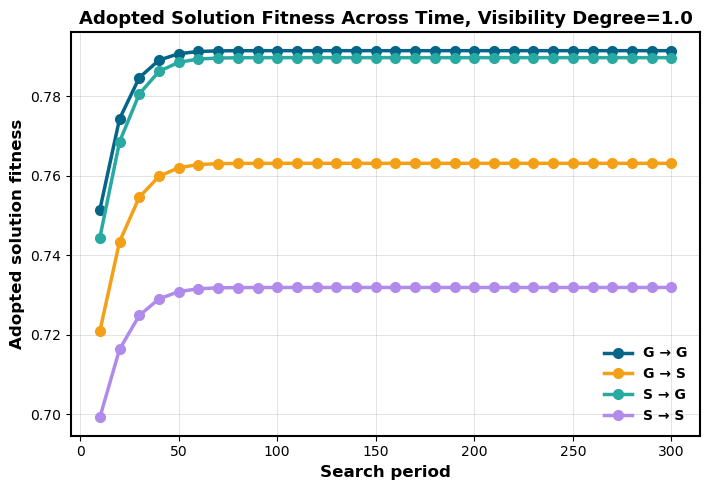

Saved: /Volumes/T7/data/gst-0924-26/Visibility_degree_low_knowledge/fig10_four_conditions_adopted_solution_fitness_across_time_visibility_1.0.png


In [26]:
# =========================
# Figure 10: Four-condition adoption-quality trajectories across time
# averaged across K at one selected visibility degree
# =========================
fig, ax = plt.subplots(figsize=(7.2, 5.0))
format_axis(ax)

for prefix in condition_order:
    # Shape at the selected visibility degree: (K, visibility event)
    trajectory_by_K = adoption_data[prefix][
        "adopted_solution_fitness_across_time"
    ][trajectory_prob_index]

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        y = np.nanmean(trajectory_by_K, axis=0)

    ax.plot(
        trajectory_periods, y,
        marker="o", linewidth=2.5, markersize=7,
        label=condition_labels[prefix],
        color=condition_colors[prefix],
    )

ax.set_xlabel("Search period", fontweight="bold", fontsize=12)
ax.set_ylabel("Adopted solution fitness", fontweight="bold", fontsize=12)
ax.set_title(
    f"Adopted Solution Fitness Across Time, "
    f"Visibility Degree={trajectory_visibility_prob}",
    fontweight="bold",
    fontsize=13,
)
ax.legend(frameon=False, prop=legend_properties)

plt.tight_layout()

output_png = result_folder / (
    f"fig10_four_conditions_adopted_solution_fitness_across_time_"
    f"visibility_{trajectory_visibility_prob}.png"
)
plt.savefig(output_png, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

print("Saved:", output_png)


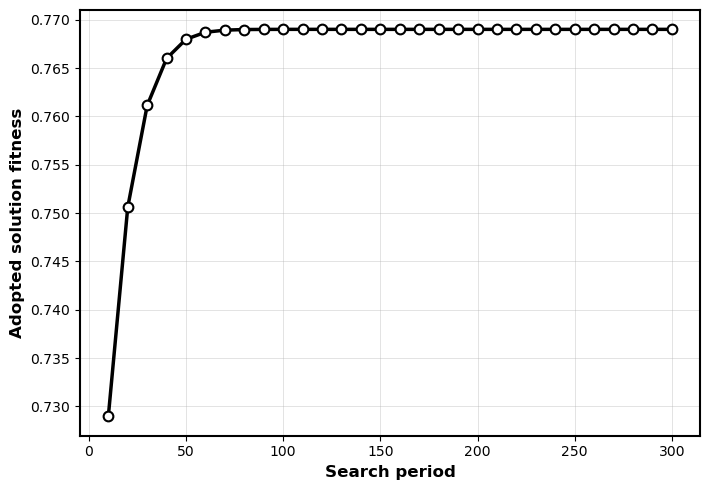

Saved: /Volumes/T7/data/gst-0924-26/Visibility_degree_low_knowledge/fig11_average_adopted_solution_fitness_across_time_visibility_1.0.png


In [27]:
# =========================
# Figure 11: Averaged adoption-quality trajectory across time
# averaged across G-S combinations and K
# =========================
fig, ax = plt.subplots(figsize=(7.2, 5.0))
format_axis(ax)

# Shape:
#   (condition, K, visibility event)
trajectory_stack = np.stack(
    [
        adoption_data[prefix]["adopted_solution_fitness_across_time"][
            trajectory_prob_index
        ]
        for prefix in condition_order
    ],
    axis=0,
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    y = np.nanmean(trajectory_stack, axis=(0, 1))

ax.plot(
    trajectory_periods, y,
    marker="o", linewidth=2.5, markersize=7, color="k",
    markerfacecolor="white",
    markeredgecolor="black",
    markeredgewidth=1.5,
)

ax.set_xlabel("Search period", fontweight="bold", fontsize=12)
ax.set_ylabel("Adopted solution fitness", fontweight="bold", fontsize=12)
# ax.set_title(
#     f"Adopted Solution Fitness Across Time, "
#     f"Visibility Degree={trajectory_visibility_prob}",
#     fontweight="bold",
#     fontsize=13,
# )

plt.tight_layout()

output_png = result_folder / (
    f"fig11_average_adopted_solution_fitness_across_time_"
    f"visibility_{trajectory_visibility_prob}.png"
)
plt.savefig(output_png, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

print("Saved:", output_png)


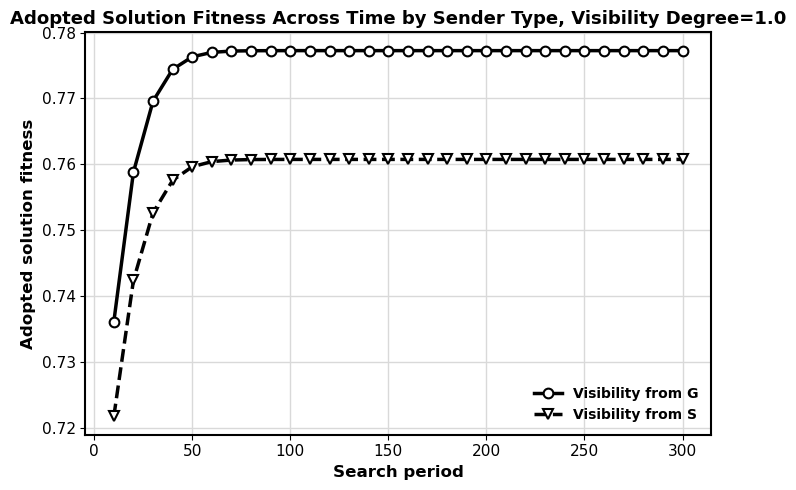

Saved: /Volumes/T7/data/gst-0924-26/Visibility_degree_low_knowledge/fig12_sender_type_adopted_solution_fitness_across_time_visibility_1.0.png


In [28]:
# =========================
# Figure 12: Sender-direction adoption-quality trajectories across time
# G as sender vs. S as sender, averaged across receiver type and K
# =========================
with plt.rc_context({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
    "grid.color": "0.85",
}):
    fig, ax = plt.subplots(figsize=(7.2, 5.0))
    format_axis(ax)

    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.5)

    ax.tick_params(axis="both", colors="black", labelsize=11)

    sender_groups = {
        "Visibility from G": ["gg", "gs"],
        "Visibility from S": ["sg", "ss"],
    }

    sender_styles = {
        "Visibility from G": {"linestyle": "-",  "marker": "o"},
        "Visibility from S": {"linestyle": "--", "marker": "v"},
    }

    for label, prefixes in sender_groups.items():
        # Shape:
        #   (receiver condition, K, visibility event)
        sender_trajectory_stack = np.stack(
            [
                adoption_data[prefix][
                    "adopted_solution_fitness_across_time"
                ][trajectory_prob_index]
                for prefix in prefixes
            ],
            axis=0,
        )

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            y = np.nanmean(sender_trajectory_stack, axis=(0, 1))

        ax.plot(
            trajectory_periods, y,
            color="black",
            linestyle=sender_styles[label]["linestyle"],
            marker=sender_styles[label]["marker"],
            linewidth=2.5,
            markersize=7,
            markerfacecolor="white",
            markeredgecolor="black",
            markeredgewidth=1.5,
            label=label,
        )

    ax.set_xlabel(
        "Search period",
        fontweight="bold",
        fontsize=12,
        color="black",
    )
    ax.set_ylabel(
        "Adopted solution fitness",
        fontweight="bold",
        fontsize=12,
        color="black",
    )
    ax.set_title(
        f"Adopted Solution Fitness Across Time by Sender Type, "
        f"Visibility Degree={trajectory_visibility_prob}",
        fontweight="bold",
        fontsize=13,
        color="black",
    )

    ax.grid(True, color="0.85", linewidth=1.0, alpha=1.0)

    legend = ax.legend(frameon=False, prop=legend_properties)
    for text in legend.get_texts():
        text.set_color("black")

    plt.tight_layout()

    output_png = result_folder / (
        f"fig12_sender_type_adopted_solution_fitness_across_time_"
        f"visibility_{trajectory_visibility_prob}.png"
    )
    plt.savefig(output_png, dpi=300, bbox_inches="tight", transparent=True)
    plt.show()

    print("Saved:", output_png)
